# ANN PART 2 
Membahas Model Breadth dan Model Depth<br>
model ini membutuhkan data yang 5.000 > keatas ya

In [1]:
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
X = df.drop(columns=['target'])
y = df['target']

In [4]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [6]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

In [7]:
model_depth = nn.Sequential(
    nn.Linear(X_train.shape[1], 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 4),
    nn.ReLU(),
    nn.Linear(4, 2),
    nn.ReLU(),
)

model_breadth = nn.Sequential(
    nn.Linear(X_train.shape[1], 128),
    nn.ReLU(),
    nn.Linear(128, 2),
)

In [8]:
def train_model_history(model, X_train, y_train, X_test, y_test, epochs=50, lr=0.01, pilihan_optimizer=1):
    loss_fun = nn.CrossEntropyLoss()
    if pilihan_optimizer == 1:
        optimizer = optim.SGD(model.parameters(), lr=lr)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)       # if else ini hanya experiment, bukan inti

    history = {
        'test_loss':[],
        'train_loss':[],
        'test_acc':[],
        'train_acc':[]
    }
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = loss_fun(outputs, y_train)   # ini adalah train_loss

        # Train accuracy
        _, train_predictions = torch.max(outputs, 1)
        train_acc = (train_predictions == y_train).sum().item() / len(y_train)

        loss.backward()
        optimizer.step()

        # Test Accuracy
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = loss_fun(test_outputs, y_test)
            _, predicted = torch.max(test_outputs, 1)
            acc = (predicted == y_test).sum() / len(y_test)

        history['test_acc'].append(acc)
        history['train_acc'].append(train_acc)
        history['train_loss'].append(loss.item())
        history['test_loss'].append(test_loss)          # meinit 47

    return history

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# History Breadth

In [10]:
history_breadth = train_model_history(model_breadth, X_train, y_train, X_test, y_test, epochs=100, lr=0.1)

In [11]:
history_breadth['test_acc'][-1]

tensor(0.8146)

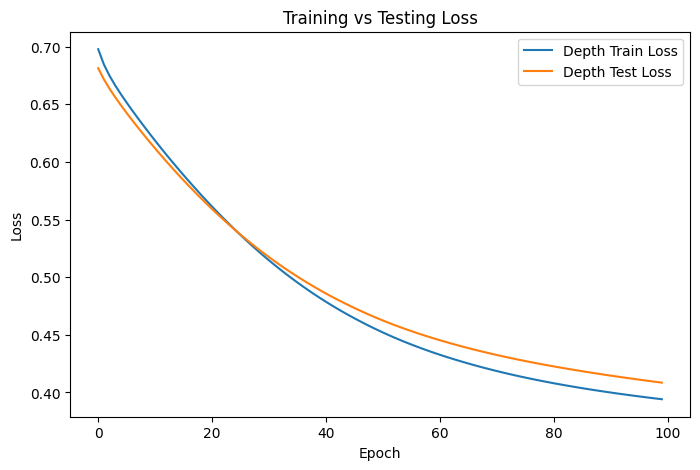

In [12]:
# cara baca graph nya. jika semakin mepet ke tembok, akan disebut underfitting karena model terlalu belajar
# tapi kalau model diagonal gembung itu disebut good model, asal menuju ke kanan nya ga terlalu terjal turun nya
plt.figure(figsize=(8,5))
plt.plot(history_breadth["train_loss"], label="Depth Train Loss")
plt.plot(history_breadth["test_loss"], label="Depth Test Loss")
plt.title("Training vs Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

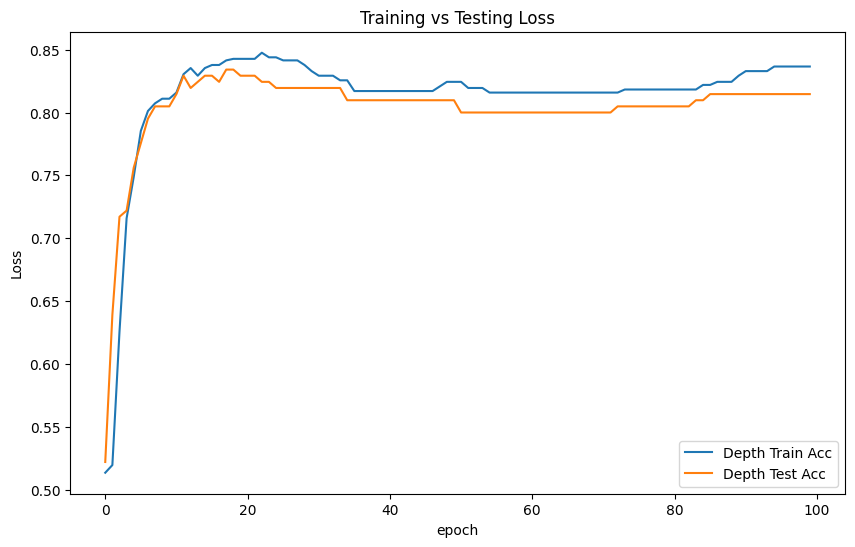

In [13]:
plt.figure(figsize=(10,6))
plt.plot(history_breadth['train_acc'], label='Depth Train Acc')
plt.plot(history_breadth['test_acc'], label='Depth Test Acc')
plt.title('Training vs Testing Loss')
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# History Depth

In [14]:
model_depth = nn.Sequential(            # di pindah ke bawah, biar ga ketimbun gitu model nya
    nn.Linear(X_train.shape[1], 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 4),
    nn.ReLU(),
    nn.Linear(4, 2),
    nn.ReLU(),
)

In [19]:
history_depth = train_model_history(model_depth, X_train, y_train, X_test, y_test, epochs=500, lr=0.1)
# epoch normal nya 100, ditambah jadi 500 karena model depth ini ga belajar anjay

In [20]:
history_depth['test_acc'][-1]       # menit 1.11. masih error di visualisasi nya woyyyyy

tensor(0.4878)

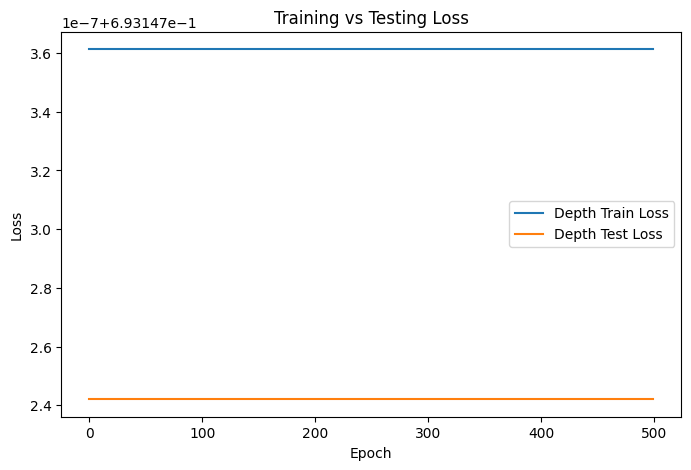

In [21]:
plt.figure(figsize=(8,5))
plt.plot(history_depth["train_loss"], label="Depth Train Loss")
plt.plot(history_depth["test_loss"], label="Depth Test Loss")
plt.title("Training vs Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**sedikit jelek visualisasi nya seperti ini dikarenakan dataset yg dipakai sangat sedikit, deep learning ini membutuhkan data yang puluhan ribu data, ribuan saja tidak cukup. Jadi ya udah lah gw gada dataset puluhan ribu**

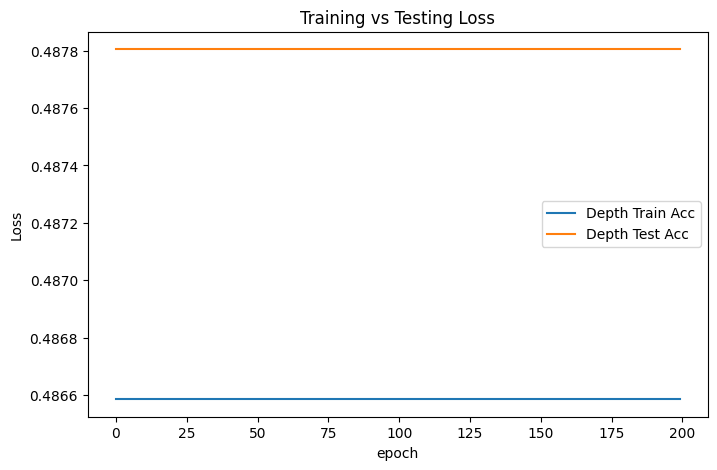

In [18]:
plt.figure(figsize=(8,5))
plt.plot(history_depth['train_acc'], label='Depth Train Acc')
plt.plot(history_depth['test_acc'], label='Depth Test Acc')
plt.title('Training vs Testing Loss')
plt.xlabel('epoch')
plt.ylabel('Loss')
# plt.ylim(bottom=0)
# plt.ylim(top=1)
plt.legend()
plt.show()